In [2]:
!pip install scikit-learn

   ---------------------------------------- 0.0/11.1 MB ? eta -:--:--
   ----------- ---------------------------- 3.1/11.1 MB 16.8 MB/s eta 0:00:01
   ----------------------------- ---------- 8.1/11.1 MB 19.4 MB/s eta 0:00:01
   ------------------------------------- -- 10.5/11.1 MB 17.2 MB/s eta 0:00:01
   ---------------------------------------- 11.1/11.1 MB 15.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/40.9 MB ? eta -:--:--
   - -------------------------------------- 1.8/40.9 MB 10.1 MB/s eta 0:00:04
   --- ------------------------------------ 3.9/40.9 MB 10.2 MB/s eta 0:00:04
   ------ --------------------------------- 6.8/40.9 MB 11.3 MB/s eta 0:00:04
   -------- ------------------------------- 8.7/40.9 MB 11.0 MB/s eta 0:00:03
   ---------- ----------------------------- 10.5/40.9 MB 10.7 MB/s eta 0:00:03
   ----------- ---------------------------- 11.3/40.9 MB 9.4 MB/s eta 0:00:04
   ------------ --------------------------- 12.3/40.9 MB 8.7 MB/s eta 0:00:04


[notice] A new release of pip is available: 25.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import sklearn.linear_model as lm
lin_reg = lm.LinearRegression()

In [4]:
data = pd.read_csv('https://raw.githubusercontent.com/yash240990/Python/master/Position_Salaries.csv')
data

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000
5,Region Manager,6,150000
6,Partner,7,200000
7,Senior Partner,8,300000
8,C-level,9,500000
9,CEO,10,1000000


In [7]:
#independent variable
x = data.Level.values
x = x.reshape(10,1)
x.shape

(10, 1)

In [8]:
#dependent variable
y = data.Salary.values
y

array([  45000,   50000,   60000,   80000,  110000,  150000,  200000,
        300000,  500000, 1000000])

In [9]:
lin_reg.fit(x,y)

LinearRegression()

In [10]:
pred_values = lin_reg.predict(x)
print(pred_values)

[-114454.54545455  -33575.75757576   47303.03030303  128181.81818182
  209060.60606061  289939.39393939  370818.18181818  451696.96969697
  532575.75757576  613454.54545455]


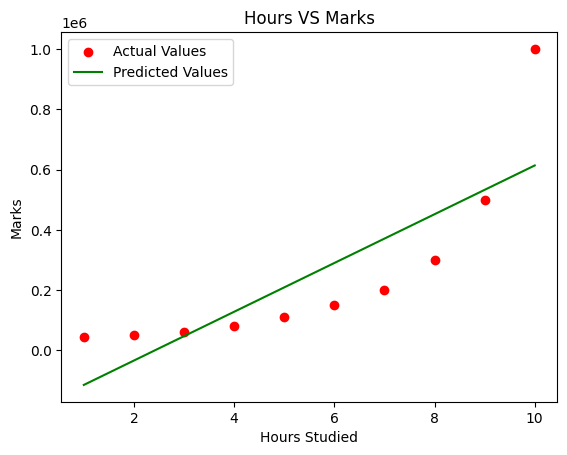

In [14]:
#plot actual values
plt.scatter(x,y,color='red',label='Actual Values')
#plotpredict values
plt.plot(x,pred_values,color='green',label='Predicted Values')
plt.title('Hours VS Marks')
plt.xlabel('Hours Studied')
plt.ylabel('Marks')
plt.legend()
plt.show()

In [15]:
from sklearn.metrics import r2_score
accuracy = r2_score(y,pred_values)
print('Regression Score :',accuracy)
print('Accuracy :',int(accuracy*100),'%')

Regression Score : 0.6690412331929895
Accuracy : 66 %


In [16]:
# Polynomial Regression is a special case of Linear Regression where we fit the polynomial equation
# on the data with a curvilinear relationship between the dependent and independent variables.

# In Polynomial Regression we increase the degree of Independent variable to increase the accuracy

from sklearn.preprocessing import PolynomialFeatures
poly_reg = PolynomialFeatures(degree=2)
x_poly_2 = poly_reg.fit_transform(x)
x_poly_2

# Generate a new feature matrix consisting of all polynomial combinations of the features

# when degree is set to 2 , 3 new feature matrix will be created   1  x*1   x*x
# when degree is set to 3 , 4 new feature matrix will be created   1  x*1   x*x  x*x*x
# when degree is set to 4 , 5 new feature matrix will be created   1  x*1   x*x  x*x*x  x*x*x*x

array([[  1.,   1.,   1.],
       [  1.,   2.,   4.],
       [  1.,   3.,   9.],
       [  1.,   4.,  16.],
       [  1.,   5.,  25.],
       [  1.,   6.,  36.],
       [  1.,   7.,  49.],
       [  1.,   8.,  64.],
       [  1.,   9.,  81.],
       [  1.,  10., 100.]])

In [18]:
lin_reg.fit(x_poly_2,y)

LinearRegression()

In [19]:
pred_values = lin_reg.predict(x_poly_2)
print(pred_values)

[118727.27272727  44151.51515151   8439.39393939  11590.90909091
  53606.06060606 134484.84848485 254227.27272727 412833.33333333
 610303.03030303 846636.36363636]


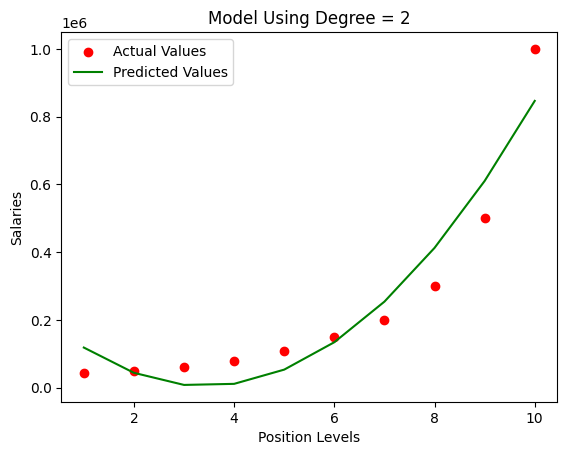

In [21]:
#plot actual values
plt.scatter(x,y,color='red',label='Actual Values')
# plot predict values
plt.plot(x,pred_values,color='green',label='Predicted Values')
plt.title('Model Using Degree = 2')
plt.xlabel('Position Levels')
plt.ylabel('Salaries')
plt.legend()
plt.show()

In [23]:
poly_reg = PolynomialFeatures(degree=3)
x_poly_3 = poly_reg.fit_transform(x)
x_poly_3

array([[   1.,    1.,    1.,    1.],
       [   1.,    2.,    4.,    8.],
       [   1.,    3.,    9.,   27.],
       [   1.,    4.,   16.,   64.],
       [   1.,    5.,   25.,  125.],
       [   1.,    6.,   36.,  216.],
       [   1.,    7.,   49.,  343.],
       [   1.,    8.,   64.,  512.],
       [   1.,    9.,   81.,  729.],
       [   1.,   10.,  100., 1000.]])

In [24]:
lin_reg.fit(x_poly_3,y)

LinearRegression()

In [25]:
pred_values = lin_reg.predict(x_poly_3)
print(pred_values)

[ 14902.09790211  78759.90675991  94960.37296037  88223.77622378
  83270.3962704  104820.51282052 177594.40559441 326312.35431236
 575694.63869463 950461.53846152]


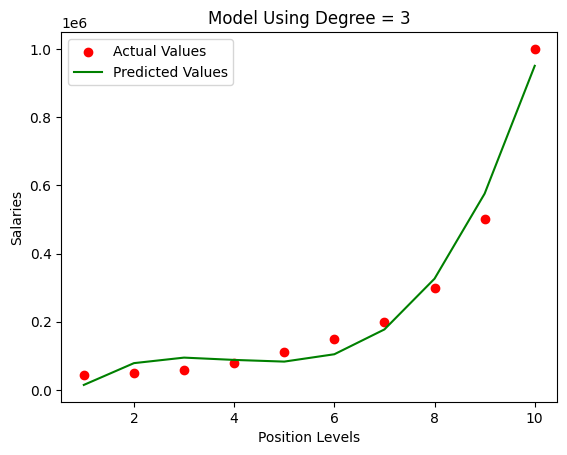

In [26]:
# plot actual values
plt.scatter(x,y,color='red',label='Actual Values')
# plot predict values
plt.plot(x,pred_values,color='green',label='Predicted Values')
plt.title('Model Using Degree = 3')
plt.xlabel('Position Levels')
plt.ylabel('Salaries')
plt.legend()
plt.show()

In [39]:
poly_reg = PolynomialFeatures(degree=4)
x_poly_4 = poly_reg.fit_transform(x)
x_poly_4

array([[1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00],
       [1.000e+00, 2.000e+00, 4.000e+00, 8.000e+00, 1.600e+01],
       [1.000e+00, 3.000e+00, 9.000e+00, 2.700e+01, 8.100e+01],
       [1.000e+00, 4.000e+00, 1.600e+01, 6.400e+01, 2.560e+02],
       [1.000e+00, 5.000e+00, 2.500e+01, 1.250e+02, 6.250e+02],
       [1.000e+00, 6.000e+00, 3.600e+01, 2.160e+02, 1.296e+03],
       [1.000e+00, 7.000e+00, 4.900e+01, 3.430e+02, 2.401e+03],
       [1.000e+00, 8.000e+00, 6.400e+01, 5.120e+02, 4.096e+03],
       [1.000e+00, 9.000e+00, 8.100e+01, 7.290e+02, 6.561e+03],
       [1.000e+00, 1.000e+01, 1.000e+02, 1.000e+03, 1.000e+04]])

In [40]:
lin_reg.fit(x_poly_4,y)

LinearRegression()

In [41]:
pred_values = lin_reg.predict(x_poly_4)
print(pred_values)

[ 53356.64335675  31759.90675984  58642.1911421   94632.86713282
 121724.94172495 143275.05827509 184003.49650352 289994.17249417
 528694.63869462 988916.08391612]


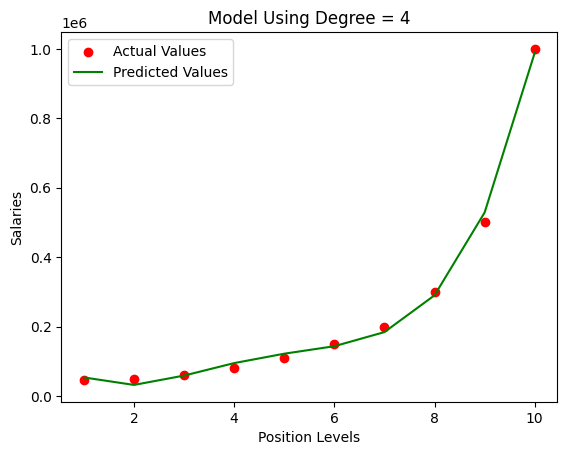

In [44]:

# plot actual values
plt.scatter(x,y,color='red',label='Actual Values')
# plot predict values
plt.plot(x,pred_values,color='green',label='Predicted Values')
plt.title('Model Using Degree = 4')
plt.xlabel('Position Levels')
plt.ylabel('Salaries')
plt.legend()
plt.show()

In [43]:
from sklearn.metrics import r2_score
accuracy = r2_score(y,pred_values)
print('Regression Score :',accuracy)
print('Accuracy :',int(accuracy*100),'%')

Regression Score : 0.9973922891706614
Accuracy : 99 %
